Opening LSEG Workspace session...
LSEG session opened.

Retrieving: Repo Rate
RIC      : INREPO=ECI
Returned shape: (193, 1)
Returned columns: ['VALUE']

Retrieving: Reverse Repo Rate
RIC      : INRREP=ECI
Returned shape: (196, 1)
Returned columns: ['VALUE']

Retrieving: Standing Deposit Facility
RIC      : INSDFR=ECI
Returned shape: (29, 1)
Returned columns: ['VALUE']

Retrieving: Marginal Standing Facility
RIC      : INMSFR=ECI
Returned shape: (35, 1)
Returned columns: ['VALUE']

Retrieving: Cash Reserve Ratio (CRR)
RIC      : INCRR=ECI
Returned shape: (183, 1)
Returned columns: ['VALUE']

Retrieving: Bank Rate (BR)
RIC      : aINBNKR
Returned shape: (859, 1)
Returned columns: ['VALUE']

Retrieving: Statutory Liquidity Ratio (SLR)
RIC      : aINSLR
Returned shape: (162, 1)
Returned columns: ['VALUE']


LSEG DATA RETRIEVAL SUMMARY

Repo Rate
---------
INREPO=ECI  VALUE
Date             
2000-06-05   9.05
2000-06-07    9.0
2000-06-09   9.05
2000-06-12   9.25
2000-06-13   9.55
INREPO=EC

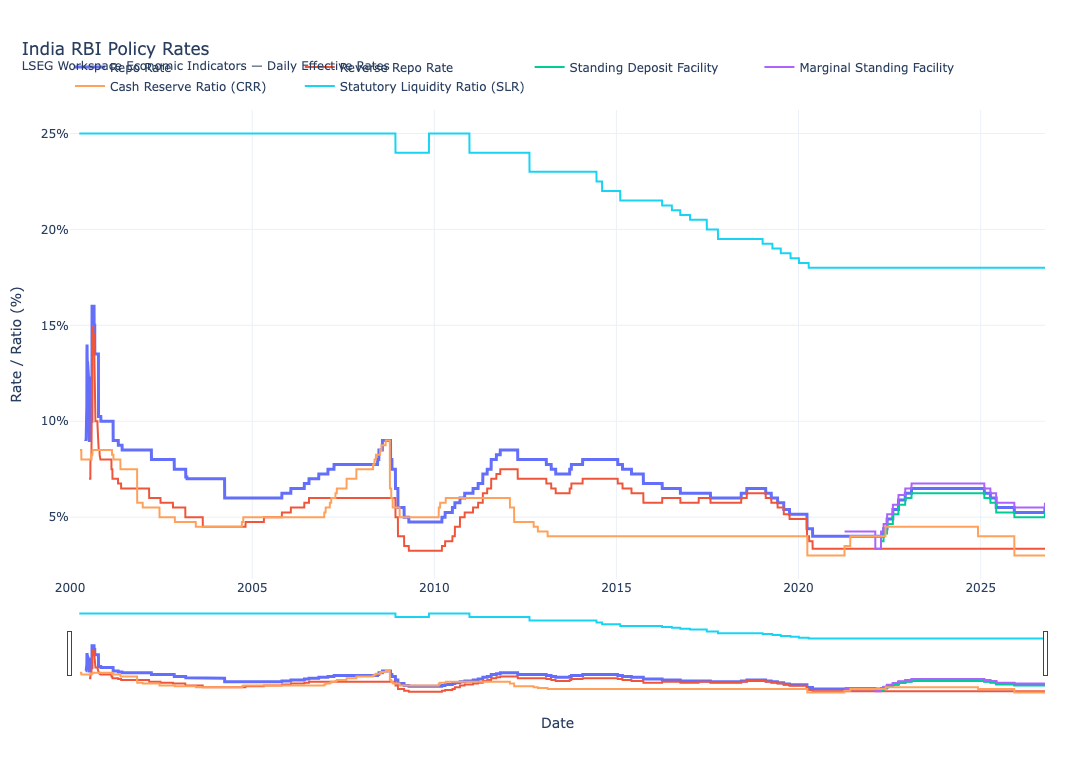

In [16]:
# =============================================================================
# INDIA RBI POLICY RATES FROM LSEG WORKSPACE
# =============================================================================
#
# Source:
#     LSEG Workspace / Economic Indicators
#
# LSEG Data Library:
#     lseg-data
#
# Purpose:
#     1. Retrieve India's RBI policy rates from LSEG Workspace
#     2. Retrieve the observations at daily frequency
#     3. Convert sparse policy-change observations into daily step functions
#     4. Plot all policy rates interactively using Plotly
#     5. Save the interactive chart as HTML
#
# =============================================================================

import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import lseg.data as ld


# =============================================================================
# 1. CONFIGURATION
# =============================================================================
# --------------------------------------------
# ========= CONFIGURE PATHS & STUBS =========
# --------------------------------------------
proj_stub = r"/Users/kalyan/Library/CloudStorage/OneDrive-Personal/Kalyan/KK-Python/Kalyan-Jupyter-Notebooks/data/"
stub = r"cpi-mospi"
byear_stub = r"2012"  # Standard CPI Base Year

BASE_DIR = f"{proj_stub}"
# RAW_DIR = os.path.join(BASE_DIR, f"raw-data/{stub}")
INTERIM_DIR = os.path.join(BASE_DIR, "interim-data")
PROCESSED_DIR = os.path.join(BASE_DIR, "proc-data")

START_DATE = "2000-01-01"
END_DATE   = pd.Timestamp.today().strftime("%Y-%m-%d")

OUTPUT_HTML = "india-rbi-policy-rates.html"
OUTPUT_EXCEL = "india-rbi-policy-rates-lseg.xlsx"


# =============================================================================
# 2. LSEG ECONOMIC INDICATOR RICS
# =============================================================================
#
# Verified India economic-indicator RICs:
#
# INREPO=ECI  -> Repo Rate
# INRREP=ECI  -> Reverse Repo Rate
# INSDFR=ECI  -> Standing Deposit Facility
# INMSFR=ECI  -> Marginal Standing Facility
# INCRR=ECI   -> Cash Reserve Ratio
# aINBNKR=ECI": "Bank Rate (BR)"
# =============================================================================

POLICY_RICS = {
    "INREPO=ECI": "Repo Rate",
    "INRREP=ECI": "Reverse Repo Rate",
    "INSDFR=ECI": "Standing Deposit Facility",
    "INMSFR=ECI": "Marginal Standing Facility",
    "INCRR=ECI": "Cash Reserve Ratio (CRR)",
    "aINBNKR": "Bank Rate (BR)",
    "aINSLR": "Statutory Liquidity Ratio (SLR)",
}


# =============================================================================
# 3. OPEN LSEG WORKSPACE SESSION
# =============================================================================

print("Opening LSEG Workspace session...")

ld.open_session()

print("LSEG session opened.")


# =============================================================================
# 4. RETRIEVE POLICY RATE DATA
# =============================================================================

raw_policy_data = {}

for ric, name in POLICY_RICS.items():

    print("\n" + "=" * 80)
    print(f"Retrieving: {name}")
    print(f"RIC      : {ric}")
    print("=" * 80)

    try:

        df = ld.get_history(
            universe=ric,
            start=START_DATE,
            end=END_DATE,
            interval="daily"
        )

        if df is None or df.empty:
            print(f"WARNING: No data returned for {ric}")
            continue

        print("Returned shape:", df.shape)
        print("Returned columns:", df.columns.tolist())

        raw_policy_data[name] = df

    except Exception as e:

        print(f"ERROR retrieving {ric}: {e}")


# =============================================================================
# 5. INSPECT LSEG OUTPUT
# =============================================================================

print("\n")
print("=" * 80)
print("LSEG DATA RETRIEVAL SUMMARY")
print("=" * 80)

for name, df in raw_policy_data.items():

    print(f"\n{name}")
    print("-" * len(name))

    print(df.head())
    print(df.tail())


# =============================================================================
# 6. STANDARDIZE EACH LSEG SERIES
# =============================================================================

def standardize_lseg_series(df, variable_name):

    """
    Convert an LSEG get_history() result into:

        date
        value
        variable

    Handles both:
        - DatetimeIndex
        - date/datetime columns
    """

    df = df.copy()

    # ---------------------------------------------------------
    # Reset index
    # ---------------------------------------------------------

    if isinstance(df.index, pd.DatetimeIndex):

        df = df.reset_index()

    elif df.index.name is not None:

        df = df.reset_index()

    # ---------------------------------------------------------
    # Identify date column
    # ---------------------------------------------------------

    date_candidates = [
        c for c in df.columns
        if str(c).strip().lower()
        in [
            "date",
            "datetime",
            "timestamp",
            "index"
        ]
    ]

    if date_candidates:

        date_col = date_candidates[0]

    else:

        # Usually first column after reset_index()
        date_col = df.columns[0]

    # ---------------------------------------------------------
    # Identify value column
    # ---------------------------------------------------------

    value_candidates = [
        c for c in df.columns
        if c != date_col
    ]

    if not value_candidates:

        raise ValueError(
            f"No value column identified for {variable_name}"
        )

    # For one economic indicator there should normally be
    # one main observation column.
    value_col = value_candidates[0]

    # ---------------------------------------------------------
    # Create standardized DataFrame
    # ---------------------------------------------------------

    out = df[[date_col, value_col]].copy()

    out.columns = [
        "date",
        "value"
    ]

    # ---------------------------------------------------------
    # Convert types
    # ---------------------------------------------------------

    out["date"] = pd.to_datetime(
        out["date"],
        errors="coerce"
    )

    out["value"] = pd.to_numeric(
        out["value"],
        errors="coerce"
    )

    # Remove timezone if necessary
    try:

        if out["date"].dt.tz is not None:

            out["date"] = (
                out["date"]
                .dt
                .tz_localize(None)
            )

    except Exception:

        pass

    # Remove invalid observations
    out = out.dropna(
        subset=["date", "value"]
    )

    # Remove duplicate dates
    out = (
        out
        .sort_values("date")
        .drop_duplicates("date", keep="last")
        .reset_index(drop=True)
    )

    out["variable"] = variable_name

    return out


# =============================================================================
# 7. STANDARDIZE ALL SERIES
# =============================================================================

standardized = {}

for name, df in raw_policy_data.items():

    try:

        standardized[name] = standardize_lseg_series(
            df,
            name
        )

        print(
            f"{name}: "
            f"{len(standardized[name])} observations"
        )

    except Exception as e:

        print(
            f"Could not standardize {name}: {e}"
        )


# =============================================================================
# 8. CREATE COMPLETE DAILY CALENDAR
# =============================================================================

daily_index = pd.date_range(
    start=START_DATE,
    end=END_DATE,
    freq="D"
)

daily_policy_rates = pd.DataFrame(
    {"date": daily_index}
)


# =============================================================================
# 9. CONVERT LSEG POLICY-CHANGE OBSERVATIONS
#    INTO DAILY STEP FUNCTIONS
# =============================================================================

for name, df in standardized.items():

    temp = df[["date", "value"]].copy()

    temp = temp.rename(
        columns={"value": name}
    )

    # ---------------------------------------------------------
    # Merge actual LSEG observations
    # ---------------------------------------------------------

    daily_policy_rates = daily_policy_rates.merge(
        temp,
        on="date",
        how="left"
    )

    # ---------------------------------------------------------
    # Forward fill the effective policy rate
    # ---------------------------------------------------------

    daily_policy_rates[name] = (
        daily_policy_rates[name]
        .ffill()
    )


# =============================================================================
# 10. DISPLAY FINAL DAILY DATASET
# =============================================================================

print("\n")
print("=" * 80)
print("DAILY RBI POLICY RATE DATA")
print("=" * 80)

print(
    daily_policy_rates.head(20)
)

print(
    daily_policy_rates.tail(20)
)


# =============================================================================
# 11. EXPORT DAILY DATA TO EXCEL
# =============================================================================

daily_policy_rates.to_excel(
    OUTPUT_EXCEL,
    index=False
)

print(
    f"\nSaved Excel file: {OUTPUT_EXCEL}"
)


# =============================================================================
# 12. PLOTLY VISUALIZATION
# =============================================================================

fig = go.Figure()


# ---------------------------------------------------------------------
# Repo Rate
# ---------------------------------------------------------------------

if "Repo Rate" in daily_policy_rates.columns:

    fig.add_trace(
        go.Scatter(
            x=daily_policy_rates["date"],
            y=daily_policy_rates["Repo Rate"],
            mode="lines",
            name="Repo Rate",
            line=dict(
                width=3
            )
        )
    )


# ---------------------------------------------------------------------
# Reverse Repo
# ---------------------------------------------------------------------

if "Reverse Repo Rate" in daily_policy_rates.columns:

    fig.add_trace(
        go.Scatter(
            x=daily_policy_rates["date"],
            y=daily_policy_rates["Reverse Repo Rate"],
            mode="lines",
            name="Reverse Repo Rate",
            line=dict(
                width=2
            )
        )
    )


# ---------------------------------------------------------------------
# SDF
# ---------------------------------------------------------------------

if "Standing Deposit Facility" in daily_policy_rates.columns:

    fig.add_trace(
        go.Scatter(
            x=daily_policy_rates["date"],
            y=daily_policy_rates[
                "Standing Deposit Facility"
            ],
            mode="lines",
            name="Standing Deposit Facility",
            line=dict(
                width=2
            )
        )
    )


# ---------------------------------------------------------------------
# MSF
# ---------------------------------------------------------------------

if "Marginal Standing Facility" in daily_policy_rates.columns:

    fig.add_trace(
        go.Scatter(
            x=daily_policy_rates["date"],
            y=daily_policy_rates[
                "Marginal Standing Facility"
            ],
            mode="lines",
            name="Marginal Standing Facility",
            line=dict(
                width=2
            )
        )
    )


# ---------------------------------------------------------------------
# CRR
# ---------------------------------------------------------------------

if "Cash Reserve Ratio (CRR)" in daily_policy_rates.columns:

    fig.add_trace(
        go.Scatter(
            x=daily_policy_rates["date"],
            y=daily_policy_rates[
                "Cash Reserve Ratio (CRR)"
            ],
            mode="lines",
            name="Cash Reserve Ratio (CRR)",
            line=dict(
                width=2
            )
        )
    )

if "Statutory Liquidity Ratio (SLR)" in daily_policy_rates.columns:

    fig.add_trace(
        go.Scatter(
            x=daily_policy_rates["date"],
            y=daily_policy_rates[
                "Statutory Liquidity Ratio (SLR)"
            ],
            mode="lines",
            name="Statutory Liquidity Ratio (SLR)",
            line=dict(
                width=2
            )
        )
    )

# =============================================================================
# 13. LAYOUT
# =============================================================================

fig.update_layout(

    title=dict(
        text=(
            "India RBI Policy Rates<br>"
            "<sup>LSEG Workspace Economic Indicators — Daily Effective Rates</sup>"
        ),
        x=0.02
    ),

    xaxis=dict(
        title="Date",
        rangeslider=dict(
            visible=True
        ),
        type="date"
    ),

    yaxis=dict(
        title="Rate / Ratio (%)",
        ticksuffix="%"
    ),

    template="plotly_white",

    hovermode="x unified",

    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0
    ),

    width=1400,
    height=750,

    margin=dict(
        l=70,
        r=40,
        t=110,
        b=70
    )
)


# =============================================================================
# 14. SAVE INTERACTIVE HTML
# =============================================================================

fig.write_html(
    OUTPUT_HTML,
    include_plotlyjs=True,
    full_html=True
)

print(
    f"Saved interactive HTML: {OUTPUT_HTML}"
)


# =============================================================================
# 15. DISPLAY
# =============================================================================

fig.show()